# Cohort Retention rate

### Import library

In [59]:
import pandas as pd
import pyodbc
import datetime as dt
from datetime import datetime
import seaborn as sns
import matplotlib.pyplot as plt

### Import data customer billing 

In [ ]:

conn = pyodbc.connect(driver = "SQL Server",
                      server='******',
                      database='******',
                      uid='******',pwd='******')
############################ CUSTOMER ##########################################
query_customer= """SELECT RWD_CARD_NO, BILLING_DATE, SUM(NET_ITEM_AMT) AS SALES, COUNT(DISTINCT ARTICLE) AS ITEM
FROM ******
WHERE BILLING_DATE BETWEEN '2024-01-01' AND '2024-12-31' AND RWD_CARD_NO IS NOT NULL AND NET_ITEM_AMT >= 0
GROUP BY RWD_CARD_NO, BILLING_DATE
"""

BILLING = pd.read_sql_query(query_customer, conn)

C:\Users\Soul\AppData\Local\Temp\ipykernel_156\4086923882.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  BILLING = pd.read_sql_query(query_customer, conn)


### Prepare data

In [52]:
BILLING.head(10)
BILLING.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15895253 entries, 0 to 15895252
Data columns (total 4 columns):
 #   Column        Dtype  
---  ------        -----  
 0   RWD_CARD_NO   object 
 1   BILLING_DATE  object 
 2   SALES         float64
 3   ITEM          int64  
dtypes: float64(1), int64(1), object(2)
memory usage: 485.1+ MB


In [53]:
BILLING['BILLING_DATE'] = pd.to_datetime(BILLING['BILLING_DATE'])
BILLING.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15895253 entries, 0 to 15895252
Data columns (total 4 columns):
 #   Column        Dtype         
---  ------        -----         
 0   RWD_CARD_NO   object        
 1   BILLING_DATE  datetime64[ns]
 2   SALES         float64       
 3   ITEM          int64         
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 485.1+ MB


### Add Cohort month column

In [62]:
def get_month(x): return dt.datetime(x.year, x.month,1)
BILLING['BILLING_MONTH'] = BILLING['BILLING_DATE'].apply(get_month)
grouping = BILLING.groupby('RWD_CARD_NO')['BILLING_MONTH']
BILLING['COHORT_MONTH'] = grouping.transform('min')
BILLING.head()

,RWD_CARD_NO,BILLING_DATE,SALES,ITEM,BILLING_MONTH,COHORT_MONTH,COHORT_INDEX
0,1000001555,2024-01-01,1404.00,3,2024-01-01,2024-01-01,1
1,1000013472,2024-01-01,1792.56,2,2024-01-01,2024-01-01,1
2,1000051072,2024-01-01,10630.00,12,2024-01-01,2024-01-01,1
3,1000096564,2024-01-01,698.00,2,2024-01-01,2024-01-01,1
4,1000111326,2024-01-01,1050.59,9,2024-01-01,2024-01-01,1


### Cohort Index

In [55]:
def get_date_int(df, column):
    year = df[column].dt.year
    month = df[column].dt.month
    day = df[column].dt.day
    return year, month, day

billing_year, billing_month, _ = get_date_int(BILLING, 'BILLING_MONTH')
cohort_year, cohort_month, _ = get_date_int(BILLING, 'COHORT_MONTH')
years_diff = billing_year - cohort_year
months_diff = billing_month - cohort_month
BILLING['COHORT_INDEX'] = years_diff * 12 + months_diff + 1
BILLING.head()

,RWD_CARD_NO,BILLING_DATE,SALES,ITEM,BILLING_MONTH,COHORT_MONTH,COHORT_INDEX
0,1000001555,2024-01-01,1404.00,3,2024-01-01,2024-01-01,1
1,1000013472,2024-01-01,1792.56,2,2024-01-01,2024-01-01,1
2,1000051072,2024-01-01,10630.00,12,2024-01-01,2024-01-01,1
3,1000096564,2024-01-01,698.00,2,2024-01-01,2024-01-01,1
4,1000111326,2024-01-01,1050.59,9,2024-01-01,2024-01-01,1


### Cohort Index count

In [63]:
BILLING['COHORT_MONTH'] = BILLING['COHORT_MONTH'].dt.strftime('%Y-%m')
grouping = BILLING.groupby(['COHORT_MONTH', 'COHORT_INDEX'])
cohort_data = grouping['RWD_CARD_NO'].apply(pd.Series.nunique)
cohort_data = cohort_data.reset_index()
cohort_counts = cohort_data.pivot(index='COHORT_MONTH',
columns='COHORT_INDEX',
values='RWD_CARD_NO')

print(cohort_counts)

COHORT_INDEX        1         2         3         4         5         6   \
COHORT_MONTH                                                               
2024-01       825102.0  338320.0  315732.0  314477.0  309936.0  294368.0   
2024-02       456714.0  138112.0  132127.0  127525.0  118965.0  115582.0   
2024-03       350290.0   94500.0   84308.0   76928.0   74065.0   72486.0   
2024-04       314306.0   72007.0   59407.0   56430.0   54173.0   51947.0   
2024-05       241857.0   50090.0   42142.0   39727.0   37480.0   38105.0   
2024-06       191275.0   37968.0   31337.0   28356.0   28385.0   26415.0   
2024-07       169620.0   32756.0   25671.0   24786.0   22491.0   25259.0   
2024-08       146883.0   26037.0   21942.0   19427.0   20968.0       NaN   
2024-09       138635.0   24391.0   18463.0   19234.0       NaN       NaN   
2024-10       131005.0   21746.0   19503.0       NaN       NaN       NaN   
2024-11       113811.0   21563.0       NaN       NaN       NaN       NaN   
2024-12     

### Retention rate

In [64]:
cohort_sizes = cohort_counts.iloc[:,0]
retention = cohort_counts.divide(cohort_sizes, axis=0)
retention.round(3) * 100

COHORT_INDEX,1,2,3,4,5,6,7,8,9,10,11,12
COHORT_MONTH,,,,,,,,,,,,
2024-01,100.0,41.0,38.3,38.1,37.6,35.7,35.0,34.5,33.4,33.8,32.9,35.8
2024-02,100.0,30.2,28.9,27.9,26.0,25.3,25.0,24.1,24.6,23.6,26.3,NaN
2024-03,100.0,27.0,24.1,22.0,21.1,20.7,20.0,20.6,19.5,21.8,NaN,NaN
2024-04,100.0,22.9,18.9,18.0,17.2,16.5,17.1,16.1,18.5,NaN,NaN,NaN
2024-05,100.0,20.7,17.4,16.4,15.5,15.8,14.8,16.7,NaN,NaN,NaN,NaN
2024-06,100.0,19.8,16.4,14.8,14.8,13.8,15.6,NaN,NaN,NaN,NaN,NaN
2024-07,100.0,19.3,15.1,14.6,13.3,14.9,NaN,NaN,NaN,NaN,NaN,NaN
2024-08,100.0,17.7,14.9,13.2,14.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-09,100.0,17.6,13.3,13.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Average Sales Cohort 

In [65]:
grouping = BILLING.groupby(['COHORT_MONTH', 'COHORT_INDEX'])
cohort_data = grouping['SALES'].mean()
cohort_data = cohort_data.reset_index()
average_quantity = cohort_data.pivot(index='COHORT_MONTH',
columns='COHORT_INDEX',
values='SALES')
average_quantity.round(1)

COHORT_INDEX,1,2,3,4,5,6,7,8,9,10,11,12
COHORT_MONTH,,,,,,,,,,,,
2024-01,4344.6,4424.3,3943.6,4231.9,3807.9,3768.7,4163.7,3633.2,3765.6,3829.5,3861.5,4092.1
2024-02,4802.6,3805.0,4179.2,3602.0,3511.8,3775.7,3349.6,3479.8,3468.0,3543.6,3758.0,NaN
2024-03,4592.4,4584.7,3892.7,3691.6,3961.7,3490.3,3553.4,3620.1,3738.3,3962.1,NaN,NaN
2024-04,5464.6,4195.1,3856.9,4175.8,3648.0,3728.2,3720.9,3795.2,4071.9,NaN,NaN,NaN
2024-05,4940.3,4163.8,4274.3,3754.3,3876.3,3819.7,3960.1,4185.4,NaN,NaN,NaN,NaN
2024-06,5011.4,4865.7,3977.2,3990.8,3937.7,3959.6,4145.7,NaN,NaN,NaN,NaN,NaN
2024-07,5834.3,4442.2,4253.0,4142.1,4214.1,4346.2,NaN,NaN,NaN,NaN,NaN,NaN
2024-08,5091.6,4701.0,4276.8,4253.7,4506.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-09,5265.2,4641.8,4625.5,4621.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Heatmap retention

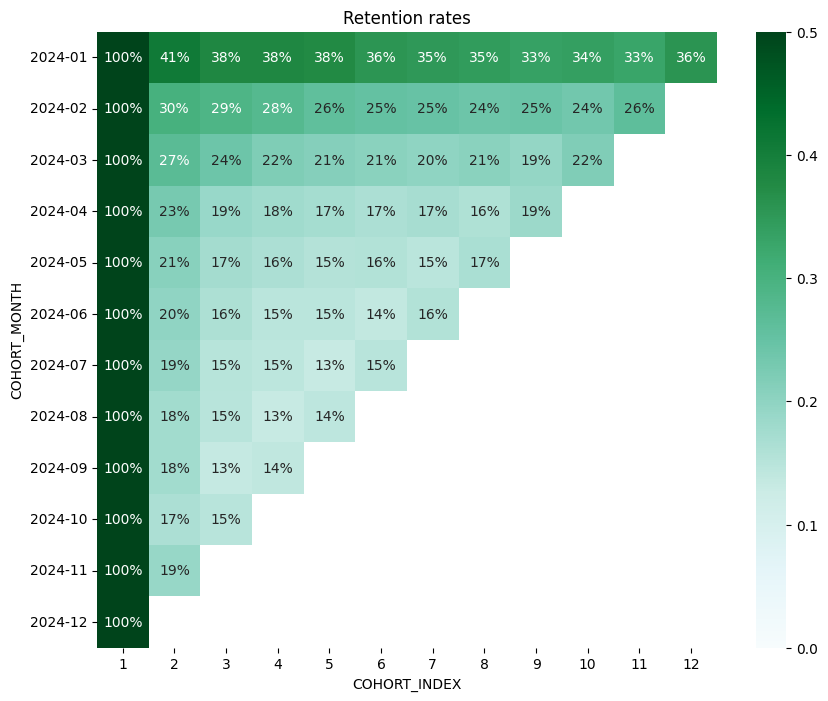

In [66]:
plt.figure(figsize=(10, 8))
plt.title('Retention rates')
sns.heatmap(data = retention,
annot = True,
fmt = '.0%',
vmin = 0.0,
vmax = 0.5,
cmap = 'BuGn')
plt.show()